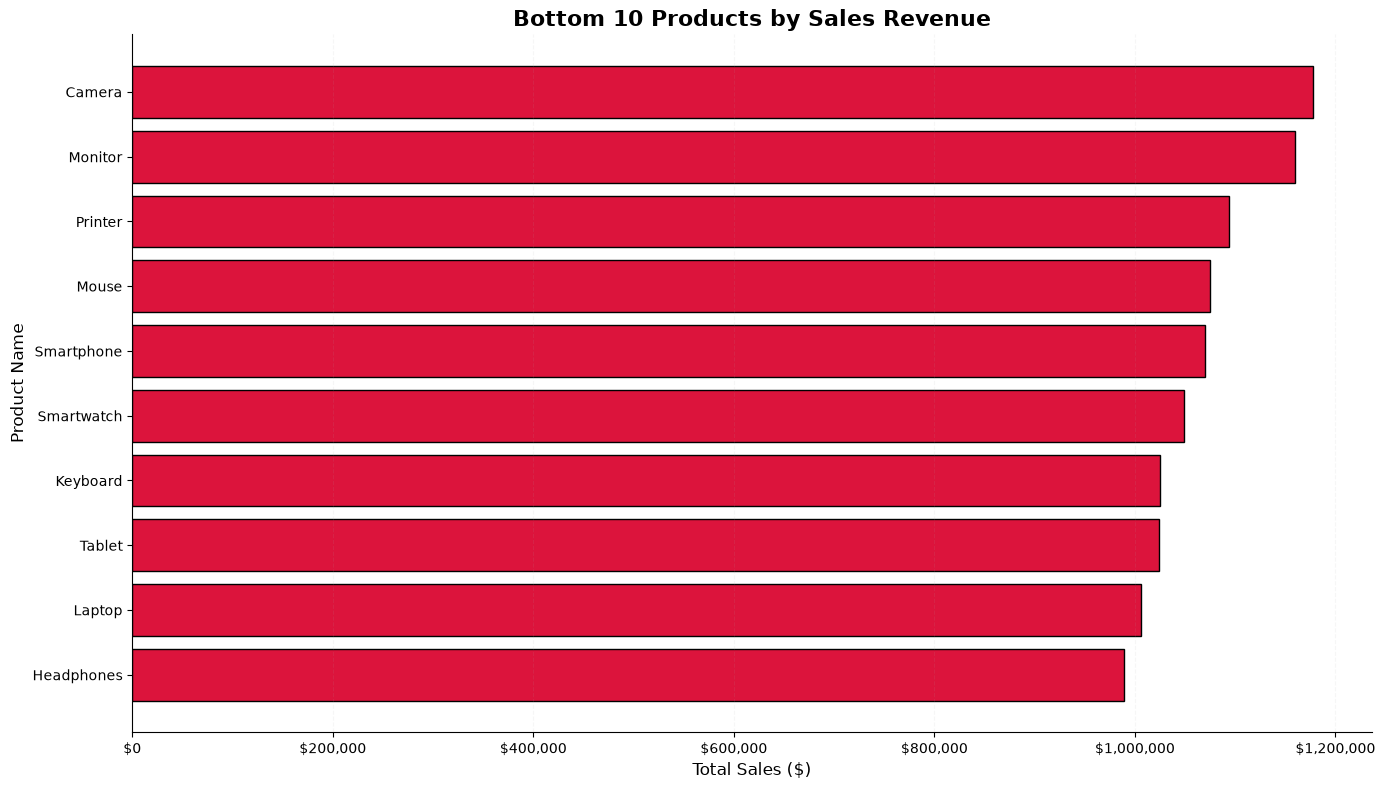

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Bottom 10 products
poor_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=True)
)

bottom_10 = poor_products.head(10)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot bars
bars = ax.barh(
    y=bottom_10.index,
    width=bottom_10.values,
    color='crimson',
    edgecolor='black'
)

# Format x-axis as currency
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

# Add data labels
# for bar in bars:
#     width = bar.get_width()

#     ax.text(
#         width,
#         bar.get_y() + bar.get_height()/2,
#         f' ${width:,.0f}',
#         va='center',
#         ha='left',
#         fontsize=10
#     )

# Titles
ax.set_title(
    'Bottom 10 Products by Sales Revenue',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Total Sales ($)',
    fontsize=12
)

ax.set_ylabel(
    'Product Name',
    fontsize=12
)

# Add grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.1
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()





In [ ]:
# Bottom Performing Products
product_sales = (
    df.groupby('Product Name')['Sales']
      .sum()
      .reset_index()
)
#products by lowest sales
poor_sales_products = product_sales.sort_values(
    by='Sales',
    ascending=True
)

poor_sales_products.head(10)

# Products with extremely low sales (threshold method)
# low_sales_products = product_sales[
#     product_sales['Sales'] < product_sales['Sales'].quantile(0.2)
# ]

# print(low_sales_products)



,Product Name,Sales
1,Headphones,988638
3,Laptop,1005873
9,Tablet,1023928
2,Keyboard,1024507
8,Smartwatch,1049211
7,Smartphone,1069681
5,Mouse,1074398
6,Printer,1094216
4,Monitor,1160048
0,Camera,1177381


In [7]:
aov = df['Sales'].sum() / len(df)

print(f"Average Order Value: ${aov:.2f}")

Average Order Value: $3047.97


In [ ]:
#Identify High-Value Customers
customer_value = (
    df.groupby('Customer ID')
      .agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum'),
          Total_Orders=('Order Date', 'count')
      )
      .reset_index()
)
print(customer_value.head(10))


#Rank Customers (High-Value Customers by total sales)
high_value_customers = customer_value.sort_values(
    by='Total_Sales',
    ascending=False
)

# Top 10 high-value customers
top_10_customers = high_value_customers.head(10)

top_10_customers

  Customer ID  Total_Sales  Total_Profit  Total_Orders
0   CUST_0001        25394       3403.82            12
1   CUST_0002        17667       2223.64             9
2   CUST_0003        30520       5066.46             9
3   CUST_0004        25029       5538.72            10
4   CUST_0005        43578       9485.49            13
5   CUST_0006         7373       1374.00             4
6   CUST_0007        25094       4945.45            10
7   CUST_0008        42262       7797.62            12
8   CUST_0009        28997       5043.57             9
9   CUST_0010        17038       4075.64             9


,Customer ID,Total_Sales,Total_Profit,Total_Orders
142,CUST_0143,62969,9806.47,13
159,CUST_0160,61992,12031.34,16
129,CUST_0130,61412,9402.84,14
221,CUST_0222,58136,6959.40,9
110,CUST_0111,56739,8411.68,13
302,CUST_0303,54874,10098.33,15
11,CUST_0012,54505,8463.43,17
172,CUST_0173,54436,7606.96,15
157,CUST_0158,53603,8556.20,14
301,CUST_0302,52340,9662.25,15


In [6]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Customer ID,Customer Name
0,2024-12-31,Printer,Office,North,4,3640,348.93,CUST_0103,Daniel Smith
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,CUST_0349,Michael Taylor
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,CUST_0271,Olivia Anderson
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,CUST_0107,Emma Thomas
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,CUST_0072,Anna Smith


In [4]:
names = ["John", "Sarah", "Michael", "Emma", "David", "Anna", "Chris", "Sophia", "Daniel", "Olivia"]
surnames = ["Smith", "Johnson", "Lee", "Brown", "Wilson", "Taylor", "Anderson", "Thomas"]

df['Customer Name'] = (
    np.random.choice(names, size=len(df)) + " " +
    np.random.choice(surnames, size=len(df))
)

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Create 400 customers
num_customers = 400
customer_pool = [f"CUST_{i:04d}" for i in range(1, num_customers + 1)]

# Assign customers to each order row
df['Customer ID'] = np.random.choice(customer_pool, size=len(df))

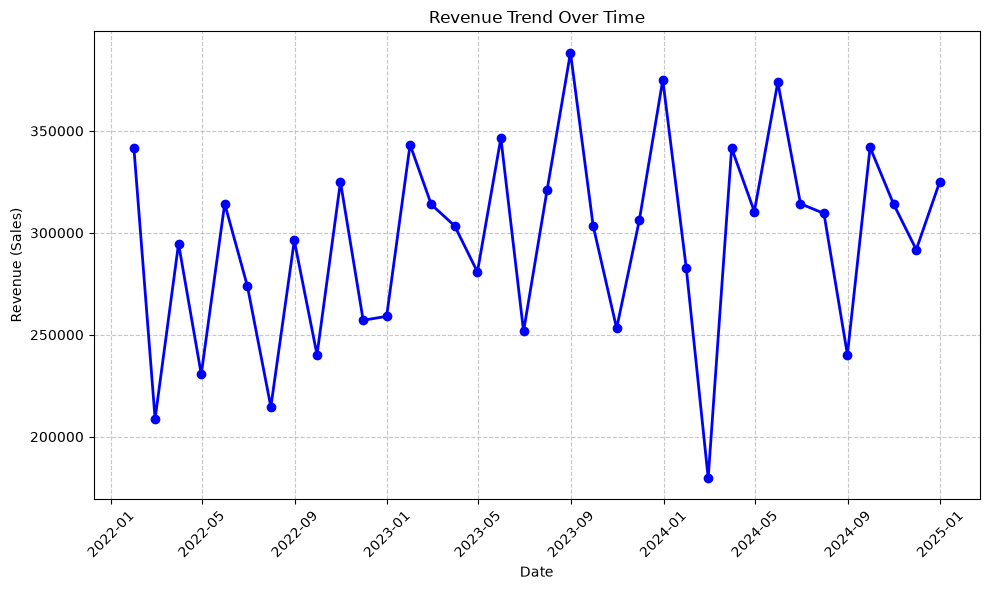

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate sales (revenue) by month
revenue_trend = (
    df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
      .sum()
      .reset_index()
)

# Plot revenue trend
plt.figure(figsize=(10, 6))
plt.plot(
    revenue_trend['Order Date'],
    revenue_trend['Sales'],
    marker='o',
    color='blue',
    linewidth=2
)

plt.title('Revenue Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (Sales)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

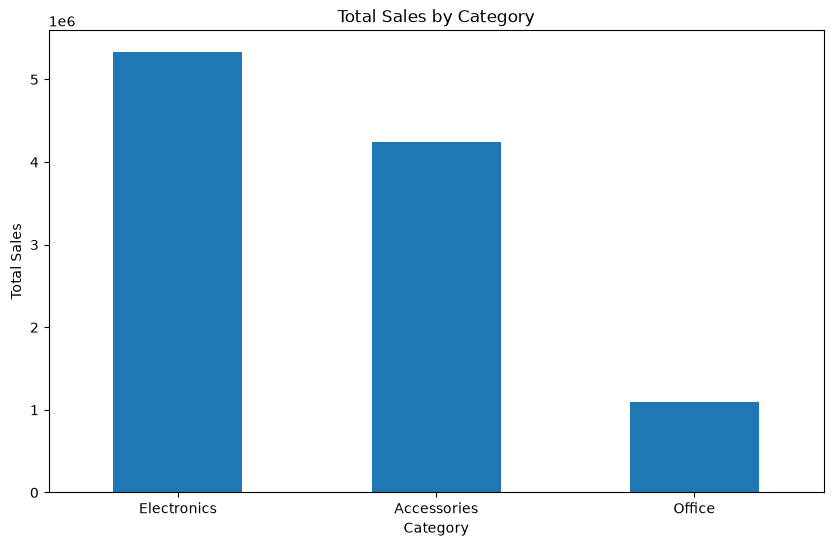

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [7]:
!pip install pandas numpy matplotlib seaborn jupyter

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for jupyter from https://files.pythonhosted.org/packages/38/64/285f20a31679bf547b75602702f7800e74dbabae36ef324f716c02804753/jupyter-1.1.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for notebook from https://files.pythonhosted.org/packages/e1/4d/b3347f7073a377273531efe4ffc738fc910e93718fd2838c7ebf6736c6af/notebook-7.5.7-py3-none-any.whl.metadata
  Obtaining dependency information for jupyter-console from https://files.pythonhosted.org/packages/ca/77/71d78d58f15c22db16328a476426f7ac4a60d3a5a7ba3b9627ee2f7903d4/jupyter_console-6.6.3-py3-none-any.whl.metadata
  Obtaining dependency information for nbconvert from https://files.pythonhosted.org/packages/67/f8/bb0a9d5f46819c821dc1f004aa2cc29b1d91453297dbf5ff20470f00f193/nbconvert-7.17.1-py3

In [6]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

#Print the total sales by category
print(category_sales)

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64


In [6]:
df.to_csv(
    '/workspaces/python-ecommerce-eda/Data/Cleaned/cleaned_ecommerce_data.csv',
    index=False
)

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])



In [11]:
# Dataset information
df.info()

# Statistical summary
print(df.describe())

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   str           
 2   Category      3500 non-null   str           
 3   Region        3500 non-null   str           
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 191.5 KB
                       Order Date     Quantity         Sales       Profit
count                        3500  3500.000000   3500.000000  3500.000000
mean   2023-07-13 00:53:53.828571     4.931714   3047.966000   527.047203
min           2022-01-01 00:00:00     1.000000     51.000000     6.970000
25%           2022-10-16 18:00:00     3.000000   1049.500000   158.695000
50%   

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/workspaces/python-ecommerce-eda/Data/Raw/ecommerce_sales_data.csv")

# View first rows
df.head()



,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
